# Data Exploration Notebook

---
embed-resources: true
---

## Methods

In [1]:
import sys
from pathlib import Path

# Get project root (one level above notebooks/)
PROJECT_ROOT = Path().resolve().parent

# Add root to Python path
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))
    
# imports
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Date & Time Handling
from datetime import datetime

# Data imports
from src.data_loader import (
    load_datathon_data,
    load_forecast_data,
    load_processed_data
)

# Utility imports
from src.utils import (
    prepare_daily_data,
    prepare_intraday_data,
    prepare_interval_data,
    fill_missing,
    add_lag_features,
    add_rolling_features,
    add_interaction_features,
    add_trend_features,
    run_validation_checks,
    print_validation_summary
)

### Data

In [2]:
# load data
data = load_datathon_data()

daily_df = data["daily"].copy()
interval_df = data["interval"].copy()
staffing_df = data["staffing"].copy()

df_forecast = load_forecast_data()
daily_by_client = data["daily_by_client"]
interval_by_client = data["interval_by_client"]

print(daily_df.head())
print(interval_df.head())
print(staffing_df.head())

           Date  Call Volume     CCT  Service Level  Abandon Rate client  \
0  01/01/24 Mon       2147.0  302.45         0.9855        0.0037      A   
1  01/02/24 Tue       7458.0  349.22         0.5213        0.1136      A   
2  01/03/24 Wed       6882.0  331.07         0.7046        0.0432      A   
3  01/04/24 Thu       6208.0  341.80         0.7200        0.0403      A   
4  01/05/24 Fri       6190.0  334.56         0.8063        0.0291      A   

  source_sheet  
0    A - Daily  
1    A - Daily  
2    A - Daily  
3    A - Daily  
4    A - Daily  
   Month  Day  Interval  Service Level  Call Volume  Abandoned Calls  \
0  April    1  00:00:00            1.0          5.0              0.0   
1  April    1  00:30:00            1.0          5.0              0.0   
2  April    1  01:00:00            1.0          4.0              0.0   
3  April    1  01:30:00            1.0          3.0              0.0   
4  April    1  02:00:00            1.0          1.0              0.0   

   Aband

#### Data Cleaning

In [3]:
# =========================================================
# Initial cleaning
# =========================================================
daily_df = prepare_daily_data(daily_df)
interval_df = prepare_interval_data(interval_df)
df_forecast = prepare_intraday_data(df_forecast)

# =========================================================
# Missing values
# =========================================================
daily_df = fill_missing(daily_df, group_col="client")
interval_df = fill_missing(interval_df, group_col="client")
df_forecast = fill_missing(df_forecast)

# =========================================================
# Feature engineering: daily
# =========================================================
daily_df = add_lag_features(daily_df, "Call Volume", group_col="client", sort_col="Date")
daily_df = add_rolling_features(daily_df, "Call Volume", group_col="client", sort_col="Date")
daily_df = add_interaction_features(daily_df)
daily_df = add_trend_features(daily_df, group_col="client")

# =========================================================
# Feature engineering: interval
# =========================================================
# replace "Call Volume" below if your interval target column is named differently
interval_df = add_lag_features(interval_df, "Call Volume", group_col="client", sort_col="datetime")
interval_df = add_rolling_features(interval_df, "Call Volume", group_col="client", sort_col="datetime")
interval_df = add_interaction_features(interval_df)
interval_df = add_trend_features(interval_df, group_col="client")

# =========================================================
# Validation
# =========================================================
validation_results = run_validation_checks(daily_df, interval_df, df_forecast)
print_validation_summary(validation_results)


DAILY DATA VALIDATION SUMMARY
Duplicate dates: 0
Negative Call Volume rows: 0
Negative CCT rows: 0
Invalid Service Level rows: 0
Invalid Abandon Rate rows: 0
All-null columns: []
Constant columns: ['hour', 'minute', 'hour_sin', 'hour_cos', 'interval_num', 'interval_sin', 'interval_cos', 'interval_x_dow']

INTERVAL DATA VALIDATION SUMMARY
Duplicate client/date/interval rows: 0
Bad interval counts: 0
All-null columns: []
Constant columns: []

FORECAST TEMPLATE VALIDATION SUMMARY
Duplicate datetimes: 0
Duplicate interval rows: 0
Bad interval counts: 0
Invalid interval format rows: 0
All-null columns: ['Calls_Offered_A', 'Abandoned_Calls_A', 'Abandoned_Rate_A', 'CCT_A', 'Calls_Offered_B', 'Abandoned_Calls_B', 'Abandoned_Rate_B', 'CCT_B', 'Calls_Offered_C', 'Abandoned_Calls_C', 'Abandoned_Rate_C', 'CCT_C', 'Calls_Offered_D', 'Abandoned_Calls_D', 'Abandoned_Rate_D', 'CCT_D']
Constant columns: ['Month', 'Calls_Offered_A', 'Abandoned_Calls_A', 'Abandoned_Rate_A', 'CCT_A', 'Calls_Offered_B', '

### Summary Statistics

In [4]:
# =========================================
# DAILY DATA SUMMARY STATISTICS
# =========================================

# Average Call Volume by Month (per client)
avg_by_month = (
    daily_df
    .groupby(['client', 'month'])['Call Volume']
    .mean()
    .unstack(level=0)
)

# Average Call Volume by Quarter (per client)
avg_by_quarter = (
    daily_df
    .groupby(['client', 'quarter'])['Call Volume']
    .mean()
    .unstack(level=0)
)

# Standard deviation of Call Volume (per client)
std_volume = (
    daily_df
    .groupby('client')['Call Volume']
    .std()
)

# Correlation between Volume and CCT (per client)
corr_volume_cct = (
    daily_df
    .groupby('client')[['Call Volume', 'CCT']]
    .corr()
)

print("\nAverage Call Volume by Month:")
print(avg_by_month)

print("\nAverage Call Volume by Quarter:")
print(avg_by_quarter)

print("\nStandard Deviation of Call Volume:")
print(std_volume)

print("\nCorrelation Between Volume and CCT:")
print(corr_volume_cct)


Average Call Volume by Month:
client            A            B             C             D
month                                                       
1       4441.193548  9736.112903  19800.258065  10635.919355
2       4136.035088  8931.824561  20502.754386  10322.035088
3       3863.790323  8453.774194  19923.080645   9818.951613
4       4130.583333  9158.116667  20141.616667  10503.400000
5       4108.354839  8823.516129  19302.854839  10557.177419
6       4260.433333  8643.883333  19631.533333  10194.433333
7       4058.645161  8946.419355  19459.951613  10367.032258
8       3844.709677  8836.919355  19172.532258  10389.145161
9       4274.700000  7616.400000  18902.716667  10100.983333
10      3870.532258  8915.919355  19159.193548  10135.725806
11      4087.316667  9118.916667  19248.283333  10257.216667
12      4735.467742  9914.370968  20462.983871  10585.419355

Average Call Volume by Quarter:
client             A            B             C             D
quarter             

In [5]:
# =========================================
# FULL CORRELATION MATRICES PER CLIENT
# =========================================

corr_matrices = {}

for client in daily_df['client'].unique():

    df_client = daily_df[
        daily_df['client'] == client
    ]

    corr_matrix = df_client.corr(
        numeric_only=True
    )

    corr_matrices[client] = corr_matrix

    print(f"\nFull Correlation Matrix — Client {client}\n")
    print(corr_matrix)


Full Correlation Matrix — Client A

                         Call Volume       CCT  Service Level  Abandon Rate  \
Call Volume                 1.000000  0.054562      -0.123221      0.077862   
CCT                         0.054562  1.000000      -0.244922      0.009648   
Service Level              -0.123221 -0.244922       1.000000     -0.768384   
Abandon Rate                0.077862  0.009648      -0.768384      1.000000   
day_of_week                -0.695615 -0.001940       0.064970     -0.039547   
month                       0.022216  0.049628       0.013578      0.003297   
day_of_month               -0.149095 -0.129717      -0.008551     -0.003330   
week_of_year                0.008054  0.021012       0.033683     -0.001103   
quarter                     0.011701  0.050262       0.009835      0.020916   
is_weekend                 -0.745307  0.029251       0.058932     -0.065526   
is_monday                   0.297444  0.031475      -0.043110      0.013748   
is_sunday      

In [6]:
# =========================================
# TOP CORRELATED FEATURES WITH TARGET
# =========================================

TARGET = "Call Volume"

top_features = {}

for client in daily_df['client'].unique():

    df_client = daily_df[
        daily_df['client'] == client
    ]

    corr = (
        df_client
        .corr(numeric_only=True)[TARGET]
        .abs()
        .sort_values(ascending=False)
    )

    top_features[client] = corr[1:15]

    print(f"\nTop Features for Client {client}")
    print(top_features[client])


Top Features for Client A
volume_x_service         0.983450
Call Volume_lag_7        0.790868
Call Volume_lag_28       0.763076
is_weekend               0.745307
is_sunday                0.741947
Call Volume_lag_14       0.739983
Call Volume_lag_21       0.729076
day_of_week              0.695615
dow_sin                  0.543819
lag7_x_weekend           0.489174
volume_x_abandon         0.388435
Call Volume_rollmax_3    0.364742
diff_lag7                0.317571
is_monday                0.297444
Name: Call Volume, dtype: float64

Top Features for Client B
volume_x_service          0.954818
is_weekend                0.717403
Call Volume_lag_7         0.712984
Call Volume_lag_28        0.701476
Call Volume_lag_14        0.673956
day_of_week               0.672209
is_sunday                 0.657730
Call Volume_lag_21        0.650698
lag7_x_weekend            0.607617
dow_sin                   0.518213
Call Volume_rollmax_3     0.401808
diff_lag7                 0.375580
is_monday       

### Exploratory Visualization

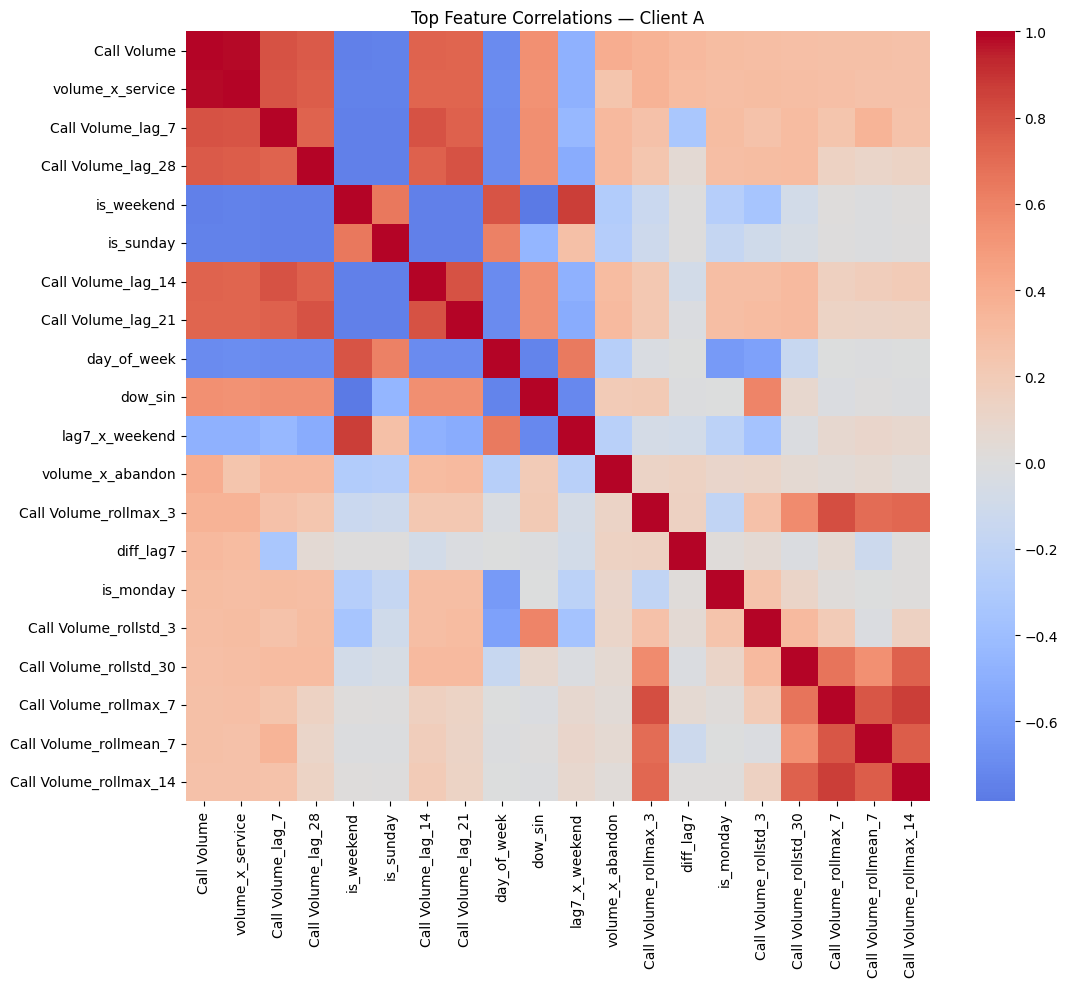

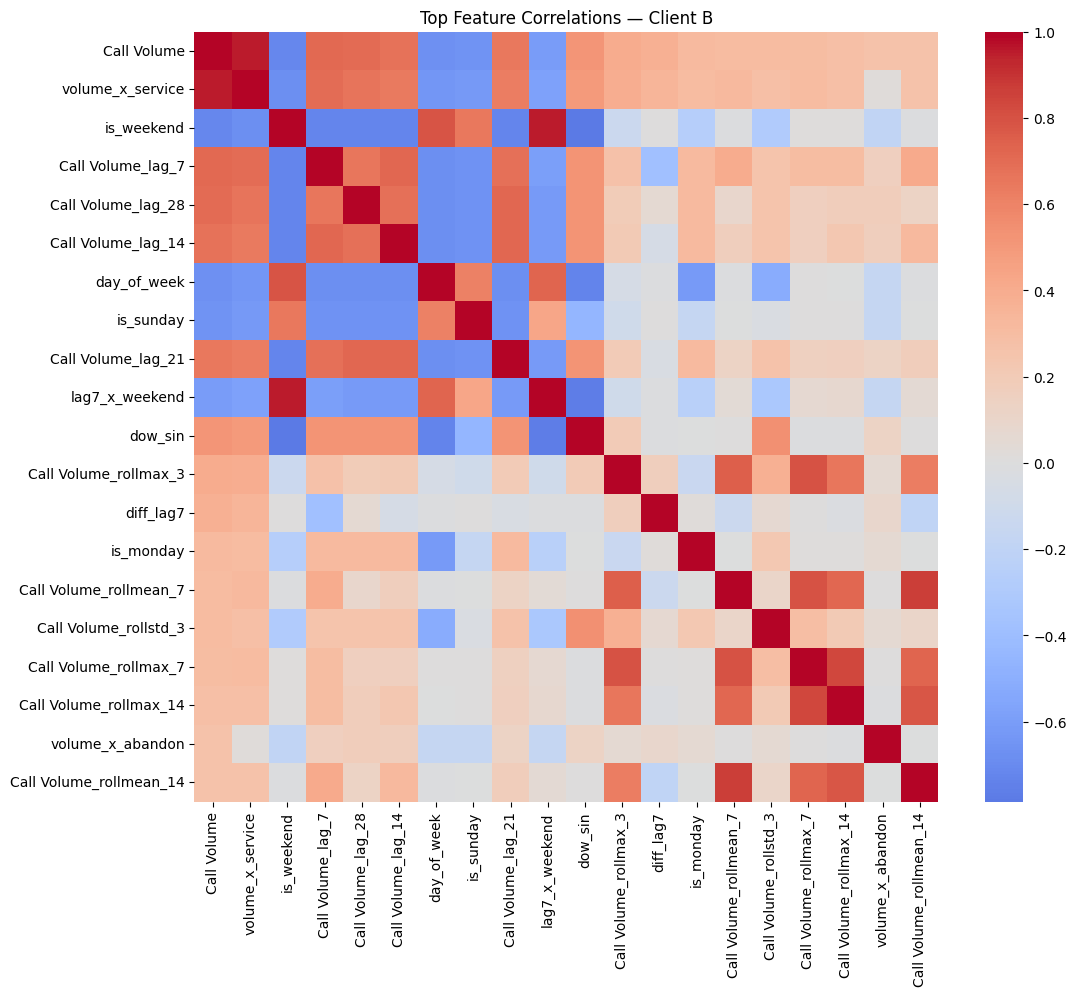

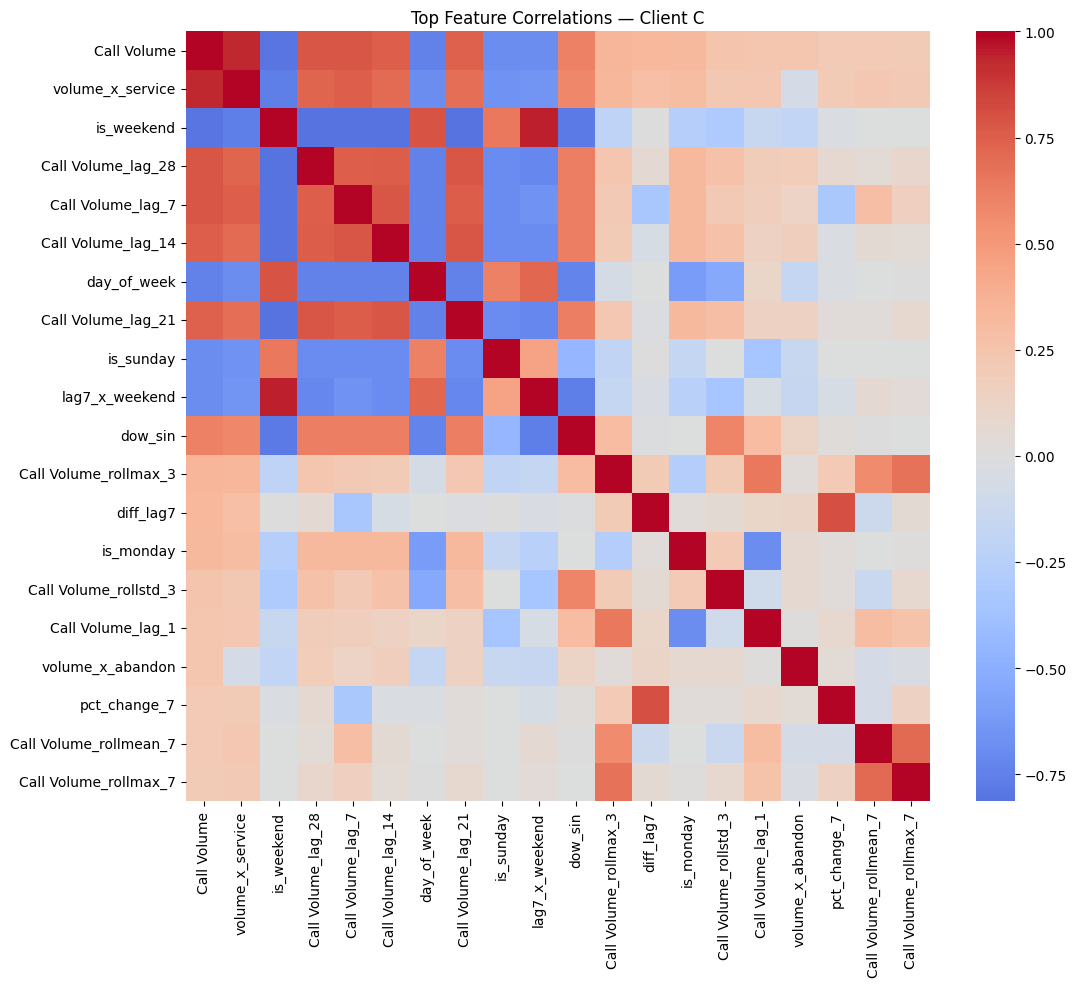

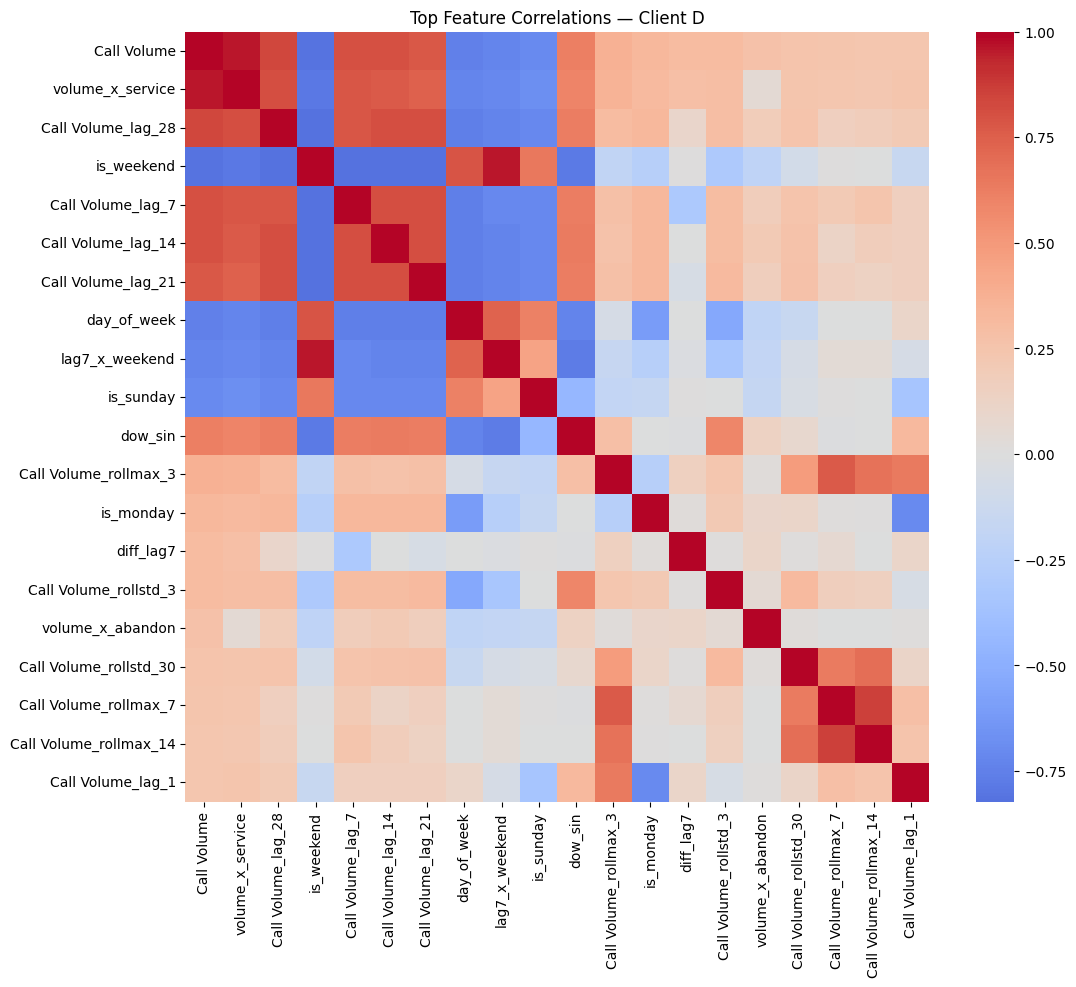

In [7]:
TARGET = "Call Volume"

for client in daily_df['client'].unique():

    df_client = daily_df[
        daily_df['client'] == client
    ]

    corr = (
        df_client
        .corr(numeric_only=True)[TARGET]
        .abs()
        .sort_values(ascending=False)
        .head(20)
    )

    selected_cols = corr.index

    corr_matrix = df_client[
        selected_cols
    ].corr()

    plt.figure(figsize=(12, 10))

    sns.heatmap(
        corr_matrix,
        annot=False,
        cmap="coolwarm",
        center=0
    )

    plt.title(
        f"Top Feature Correlations — Client {client}"
    )

    plt.savefig(
        f"outputs/client_{client}/top_features_corr_client.png",
        bbox_inches="tight"
    )

    plt.show()

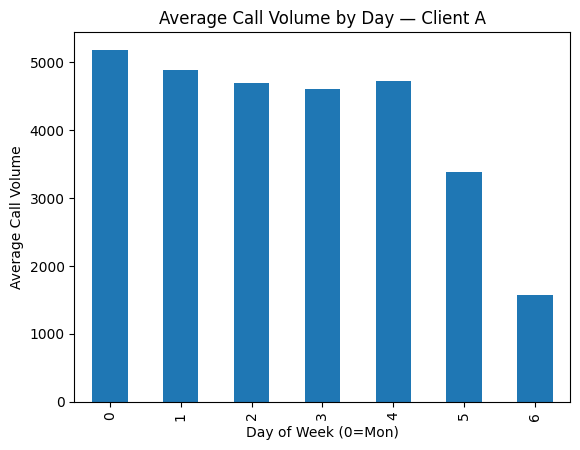

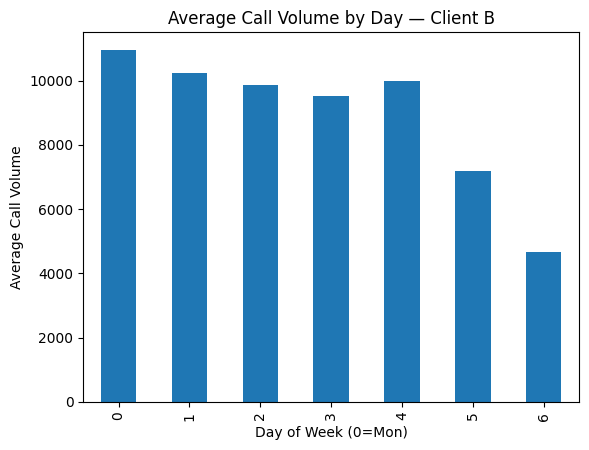

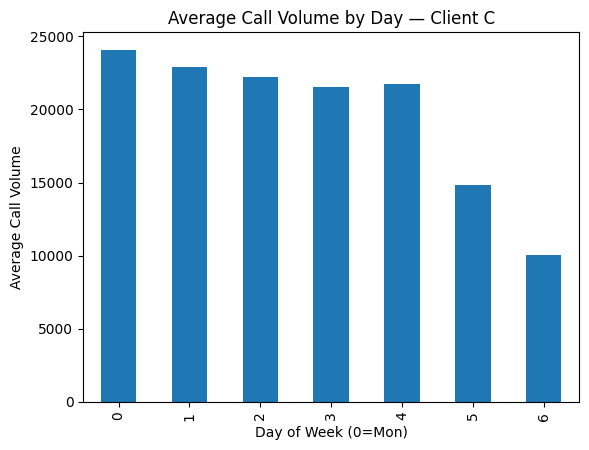

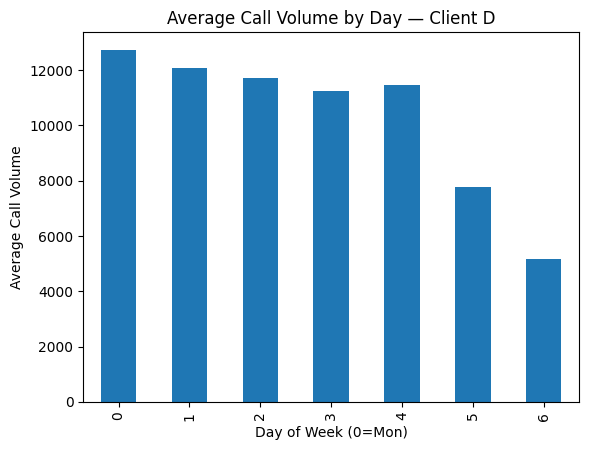

In [8]:
for client in daily_df['client'].unique():

    df_client = daily_df[
        daily_df['client'] == client
    ]

    avg_by_dow = (
        df_client
        .groupby("day_of_week")["Call Volume"]
        .mean()
    )

    plt.figure()

    avg_by_dow.plot(kind="bar")

    plt.title(
        f"Average Call Volume by Day — Client {client}"
    )

    plt.xlabel("Day of Week (0=Mon)")
    plt.ylabel("Average Call Volume")

    plt.savefig(
        f"outputs/client_{client}/avg_volume_by_day_of_week.png"
    )

    plt.show()

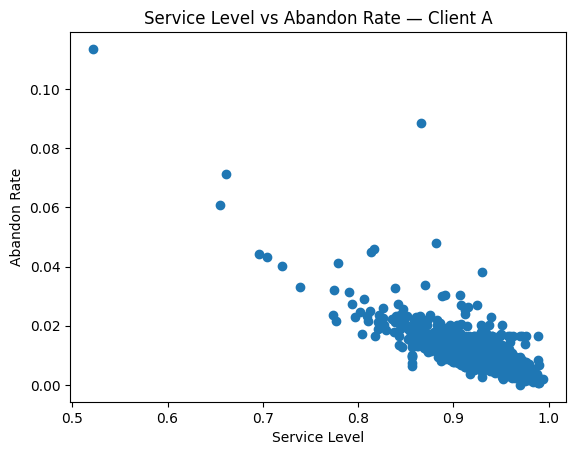

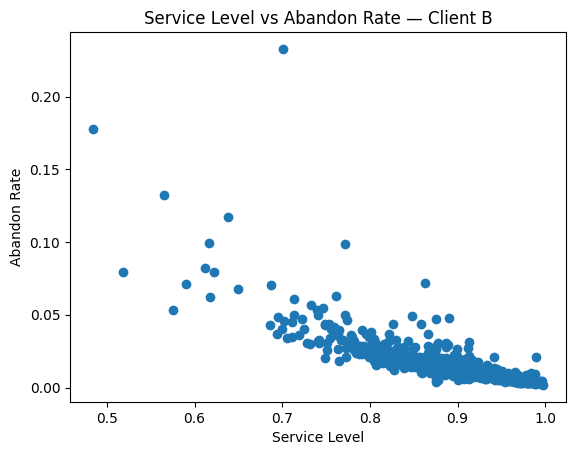

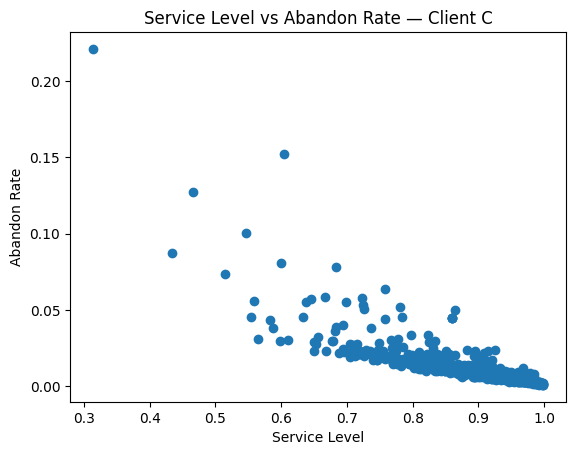

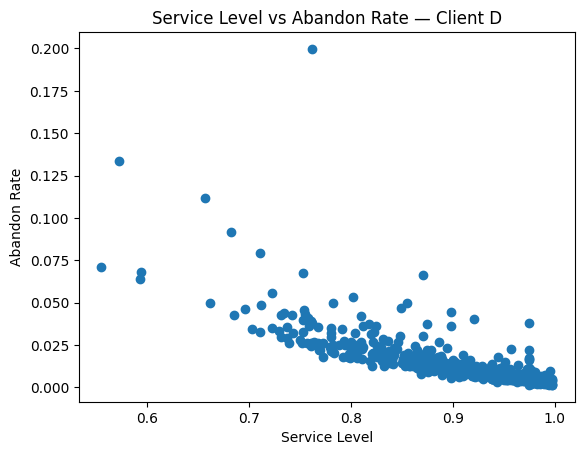

In [9]:
for client in daily_df['client'].unique():

    df_client = daily_df[
        daily_df['client'] == client
    ]

    plt.figure()

    plt.scatter(
        df_client["Service Level"],
        df_client["Abandon Rate"]
    )

    plt.title(
        f"Service Level vs Abandon Rate — Client {client}"
    )

    plt.xlabel("Service Level")
    plt.ylabel("Abandon Rate")

    plt.savefig(
        f"outputs/client_{client}/service_vs_abandon.png"
    )

    plt.show()

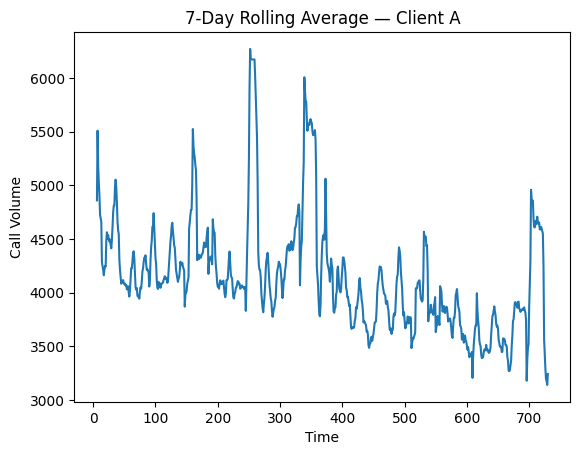

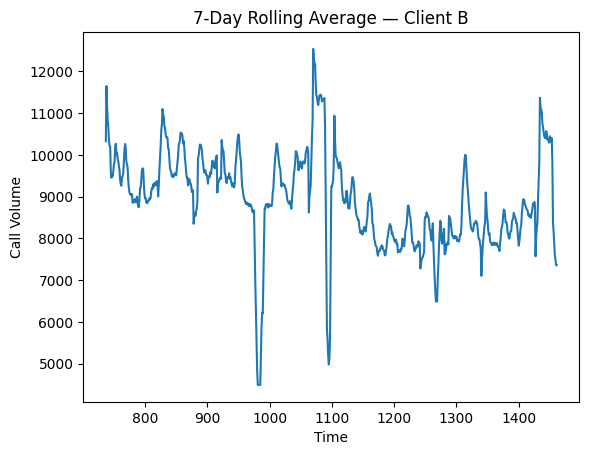

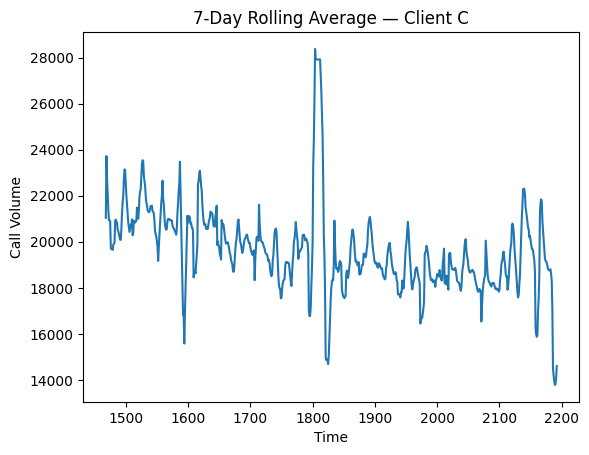

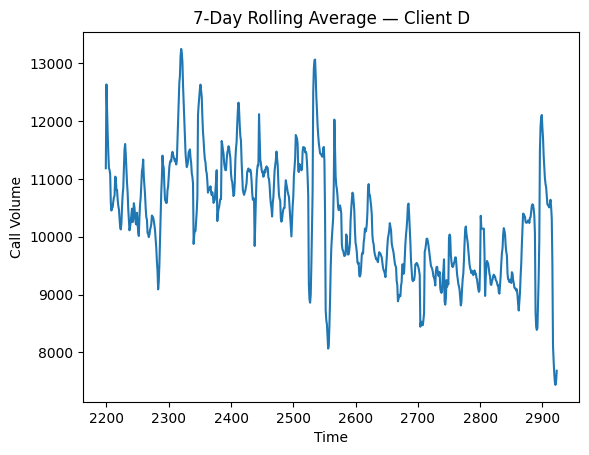

In [10]:
for client in daily_df['client'].unique():

    df_client = (
        daily_df[
            daily_df['client'] == client
        ]
        .sort_values("Date")
    )

    rolling_mean = (
        df_client["Call Volume"]
        .rolling(7)
        .mean()
    )

    plt.figure()

    rolling_mean.plot()

    plt.title(
        f"7-Day Rolling Average — Client {client}"
    )

    plt.xlabel("Time")
    plt.ylabel("Call Volume")

    plt.savefig(
        f"outputs/client_{client}/rolling_7day_volume.png"
    )

    plt.show()

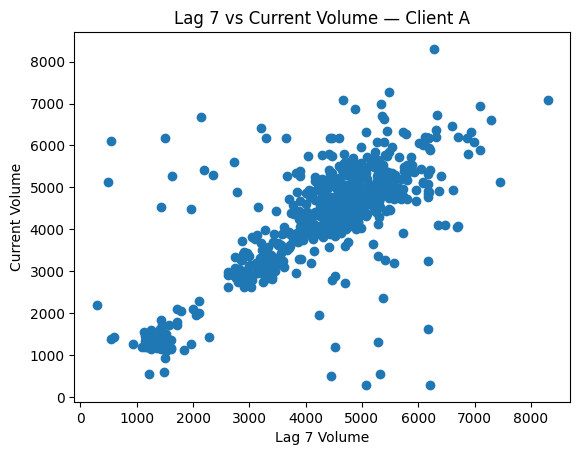

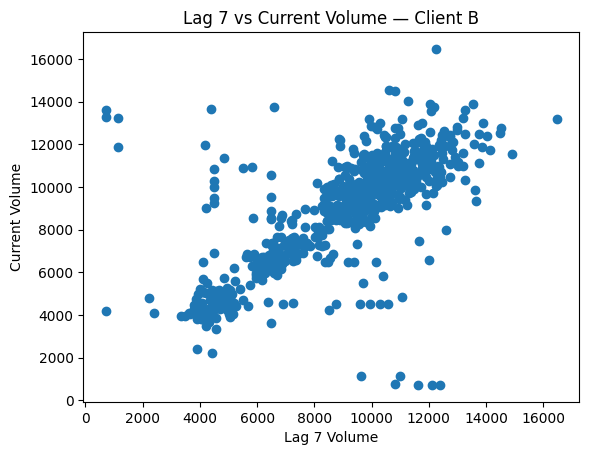

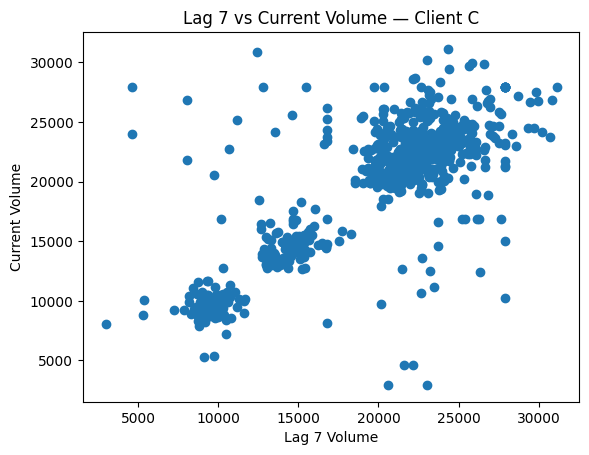

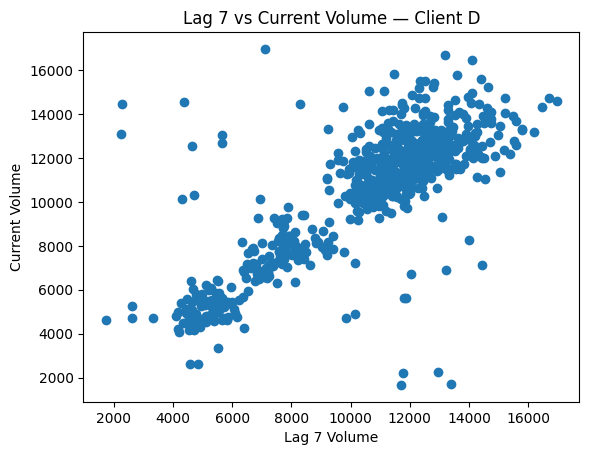

In [11]:
for client in daily_df['client'].unique():

    df_client = daily_df[
        daily_df['client'] == client
    ]

    plt.figure()

    plt.scatter(
        df_client["Call Volume_lag_7"],
        df_client["Call Volume"]
    )

    plt.title(
        f"Lag 7 vs Current Volume — Client {client}"
    )

    plt.xlabel("Lag 7 Volume")
    plt.ylabel("Current Volume")

    plt.savefig(
        f"outputs/client_{client}/lag7_relationship.png"
    )

    plt.show()

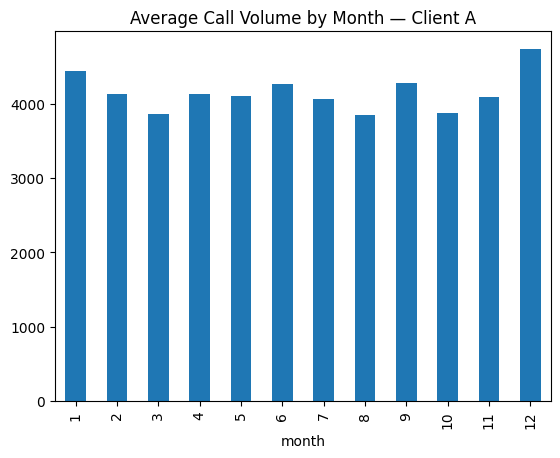

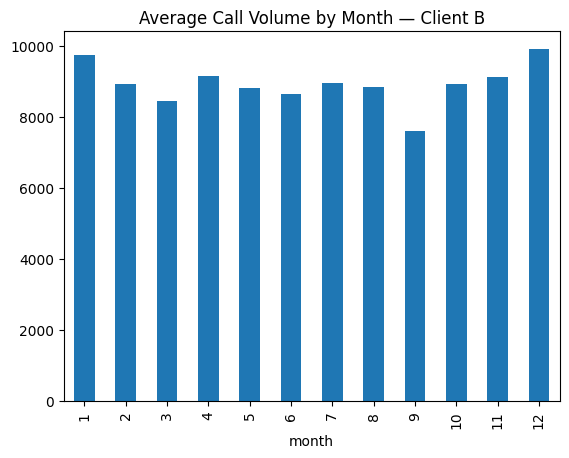

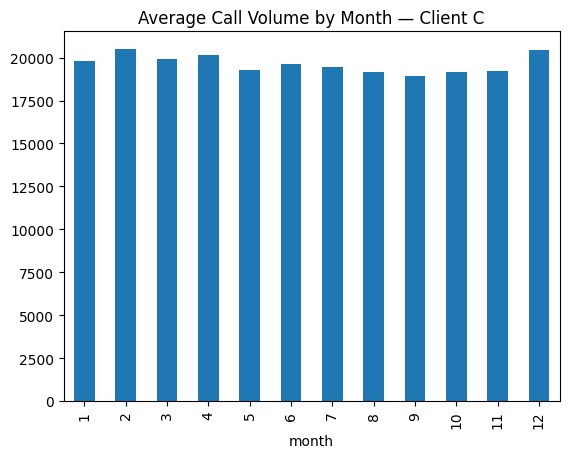

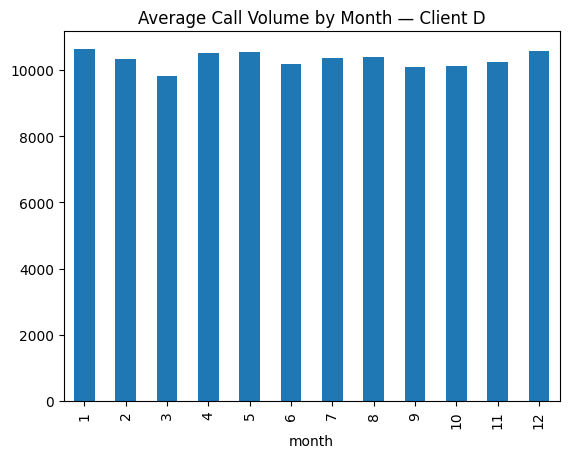

In [12]:
for client in daily_df['client'].unique():

    df_client = daily_df[
        daily_df['client'] == client
    ]

    avg_by_month = (
        df_client
        .groupby("month")["Call Volume"]
        .mean()
    )

    plt.figure()

    avg_by_month.plot(kind="bar")

    plt.title(
        f"Average Call Volume by Month — Client {client}"
    )

    plt.savefig(
        f"outputs/client_{client}/avg_volume_by_month.png"
    )

    plt.show()

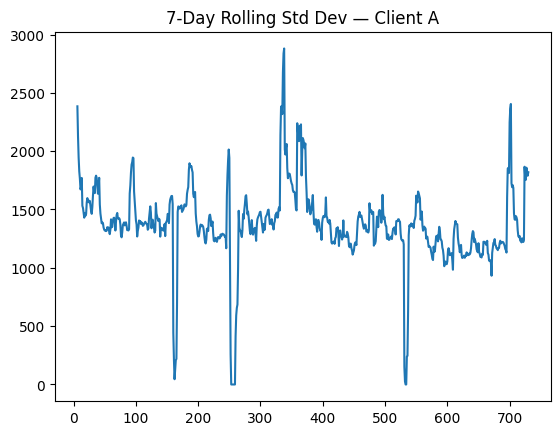

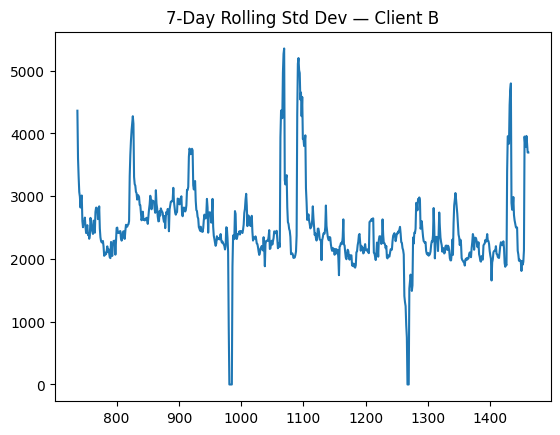

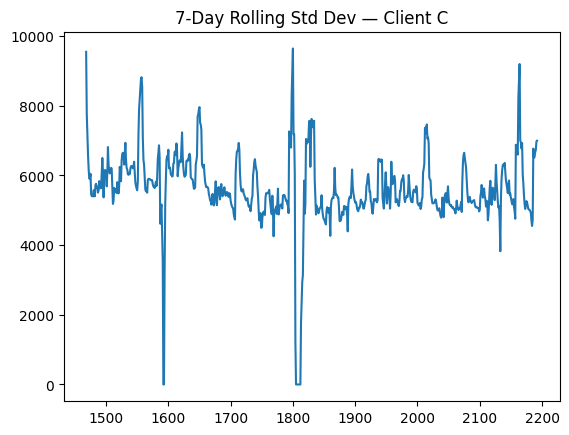

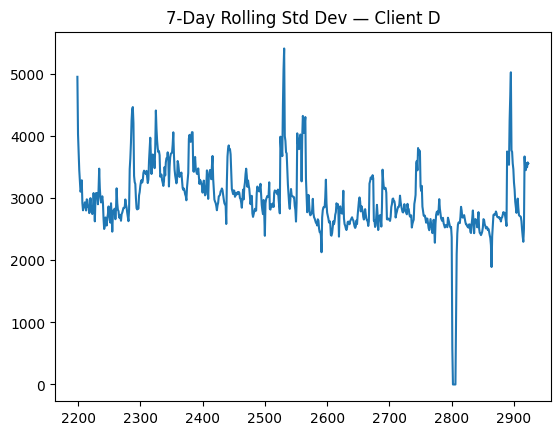

In [13]:
for client in daily_df['client'].unique():

    df_client = (
        daily_df[
            daily_df['client'] == client
        ]
        .sort_values("Date")
    )

    rolling_std = (
        df_client["Call Volume"]
        .rolling(7)
        .std()
    )

    plt.figure()

    rolling_std.plot()

    plt.title(
        f"7-Day Rolling Std Dev — Client {client}"
    )

    plt.savefig(
        f"outputs/client_{client}/rolling_std_7.png"
    )

    plt.show()

features to maybe drop later:
- volume_x_service
- volume_x_abandon
- lag7_x_weekend
- trend_squared
- month
- quarter

In [14]:
validation_results = run_validation_checks(
    df_daily=daily_df,
    df_interval=interval_df,
    df_forecast=df_forecast
)

print_validation_summary(validation_results)


DAILY DATA VALIDATION SUMMARY
Duplicate dates: 0
Negative Call Volume rows: 0
Negative CCT rows: 0
Invalid Service Level rows: 0
Invalid Abandon Rate rows: 0
All-null columns: []
Constant columns: ['hour', 'minute', 'hour_sin', 'hour_cos', 'interval_num', 'interval_sin', 'interval_cos', 'interval_x_dow']

INTERVAL DATA VALIDATION SUMMARY
Duplicate client/date/interval rows: 0
Bad interval counts: 0
All-null columns: []
Constant columns: []

FORECAST TEMPLATE VALIDATION SUMMARY
Duplicate datetimes: 0
Duplicate interval rows: 0
Bad interval counts: 0
Invalid interval format rows: 0
All-null columns: ['Calls_Offered_A', 'Abandoned_Calls_A', 'Abandoned_Rate_A', 'CCT_A', 'Calls_Offered_B', 'Abandoned_Calls_B', 'Abandoned_Rate_B', 'CCT_B', 'Calls_Offered_C', 'Abandoned_Calls_C', 'Abandoned_Rate_C', 'CCT_C', 'Calls_Offered_D', 'Abandoned_Calls_D', 'Abandoned_Rate_D', 'CCT_D']
Constant columns: ['Month', 'Calls_Offered_A', 'Abandoned_Calls_A', 'Abandoned_Rate_A', 'CCT_A', 'Calls_Offered_B', '

### Feature Engineering

In [16]:
print("\nALL DAILY FEATURES:")
print("=" * 50)

for col in daily_df.columns:
    print(col)

print("\nTotal Daily Features:", len(daily_df.columns))


ALL DAILY FEATURES:
Date
Call Volume
CCT
Service Level
Abandon Rate
client
source_sheet
Date_raw
day_of_week
day_name
month
month_name
day_of_month
week_of_year
quarter
quarter_label
is_weekend
is_monday
is_sunday
is_month_start
is_month_end
is_pay_period
dow_sin
dow_cos
month_sin
month_cos
hour
minute
hour_sin
hour_cos
interval_num
interval_sin
interval_cos
Call Volume_lag_1
Call Volume_lag_2
Call Volume_lag_7
Call Volume_lag_14
Call Volume_lag_21
Call Volume_lag_28
Call Volume_rollmean_3
Call Volume_rollstd_3
Call Volume_rollmin_3
Call Volume_rollmax_3
Call Volume_rollmean_7
Call Volume_rollstd_7
Call Volume_rollmin_7
Call Volume_rollmax_7
Call Volume_rollmean_14
Call Volume_rollstd_14
Call Volume_rollmin_14
Call Volume_rollmax_14
Call Volume_rollmean_30
Call Volume_rollstd_30
Call Volume_rollmin_30
Call Volume_rollmax_30
diff_lag7
pct_change_7
volatility_ratio
volume_x_service
volume_x_abandon
lag7_x_weekend
interval_x_dow
trend
trend_squared

Total Daily Features: 64


In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
from pathlib import Path

# =========================================================
# SETTINGS
# =========================================================
TARGET = "Call Volume"
N_SPLITS = 5

# columns to exclude from modeling
BASE_DROP_COLS = [
    TARGET,
    "Date",
    "Date_raw",
    "day_name",
    "month_name",
    "quarter_label",
    "source_sheet"
]

# optional columns that should not be in daily modeling
DAILY_BAD_COLS = [
    "hour",
    "minute",
    "hour_sin",
    "hour_cos",
    "interval_num",
    "interval_sin",
    "interval_cos",
    "interval_x_dow"
]

# output folders
Path("outputs").mkdir(exist_ok=True)

# =========================================================
# MAIN CONTAINER
# =========================================================
client_results = {}
all_importances = []

# =========================================================
# TRAIN ONE MODEL PER CLIENT
# =========================================================
for client in sorted(daily_df["client"].dropna().unique()):

    print("=" * 60)
    print(f"TRAINING CLIENT {client}")
    print("=" * 60)

    # -----------------------------------------
    # 1. SUBSET CLIENT DATA
    # -----------------------------------------
    df_client = (
        daily_df[daily_df["client"] == client]
        .copy()
        .sort_values("Date")
        .reset_index(drop=True)
    )

    # create client output folder
    client_dir = Path(f"outputs/client_{client}")
    client_dir.mkdir(parents=True, exist_ok=True)

    # -----------------------------------------
    # 2. DEFINE X / y
    # -----------------------------------------
    drop_cols = BASE_DROP_COLS + DAILY_BAD_COLS + ["client"]
    drop_cols = [col for col in drop_cols if col in df_client.columns]

    X = df_client.drop(columns=drop_cols)
    y = df_client[TARGET]

    # remove rows with missing target
    mask = y.notna()
    X = X.loc[mask].copy()
    y = y.loc[mask].copy()
    df_client = df_client.loc[mask].copy()

    # -----------------------------------------
    # 3. HANDLE NON-NUMERIC COLUMNS
    # -----------------------------------------
    for col in X.columns:
        if X[col].dtype == "object":
            X[col] = X[col].astype("category").cat.codes

    # drop columns that are fully null
    null_cols = X.columns[X.isna().all()].tolist()
    if null_cols:
        X = X.drop(columns=null_cols)

    # drop constant columns
    constant_cols = [col for col in X.columns if X[col].nunique(dropna=True) <= 1]
    if constant_cols:
        X = X.drop(columns=constant_cols)

    print(f"Rows: {len(X)}")
    print(f"Features: {X.shape[1]}")

    # need enough rows for CV
    if len(X) <= N_SPLITS + 1:
        print(f"Skipping client {client}: not enough rows for TimeSeriesSplit.")
        continue

    # -----------------------------------------
    # 4. TIME SERIES CROSS-VALIDATION
    # -----------------------------------------
    tscv = TimeSeriesSplit(n_splits=N_SPLITS)

    mae_scores = []
    rmse_scores = []
    r2_scores = []
    models = []
    feature_importances = []

    # -----------------------------------------
    # 5. TRAIN LIGHTGBM
    # -----------------------------------------
    for fold, (train_idx, test_idx) in enumerate(tscv.split(X), start=1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model = lgb.LGBMRegressor(
            objective="regression",
            n_estimators=1000,
            learning_rate=0.03,
            num_leaves=31,
            max_depth=-1,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42
        )

        model.fit(
            X_train,
            y_train,
            eval_set=[(X_test, y_test)],
            eval_metric="l2"
        )

        preds = model.predict(X_test)

        mae = mean_absolute_error(y_test, preds)
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        r2 = r2_score(y_test, preds)

        mae_scores.append(mae)
        rmse_scores.append(rmse)
        r2_scores.append(r2)

        models.append(model)

        fold_importance = pd.DataFrame({
            "client": client,
            "feature": X.columns,
            "importance": model.feature_importances_,
            "fold": fold
        })
        feature_importances.append(fold_importance)

        print(f"Fold {fold}")
        print(f"MAE:  {mae:.3f}")
        print(f"RMSE: {rmse:.3f}")
        print(f"R^2:  {r2:.3f}")
        print("-" * 40)

    # -----------------------------------------
    # 6. CV RESULTS
    # -----------------------------------------
    avg_mae = np.mean(mae_scores)
    avg_rmse = np.mean(rmse_scores)
    avg_r2 = np.mean(r2_scores)

    print(f"Average CV Results — Client {client}")
    print(f"MAE:  {avg_mae:.3f}")
    print(f"RMSE: {avg_rmse:.3f}")
    print(f"R^2:  {avg_r2:.3f}")

    # -----------------------------------------
    # 7. FEATURE IMPORTANCE SUMMARY
    # -----------------------------------------
    importance_df = pd.concat(feature_importances, axis=0)

    importance_summary = (
        importance_df.groupby(["client", "feature"])["importance"]
        .mean()
        .reset_index()
        .sort_values("importance", ascending=False)
    )

    print(f"\nTop 20 Features — Client {client}")
    print(importance_summary.head(20))

    # save importance table
    importance_summary.to_csv(
        client_dir / "lightgbm_feature_importance.csv",
        index=False
    )

    # save fold metrics
    metrics_df = pd.DataFrame({
        "fold": list(range(1, len(mae_scores) + 1)),
        "mae": mae_scores,
        "rmse": rmse_scores,
        "r2": r2_scores
    })
    metrics_df.to_csv(client_dir / "lightgbm_cv_metrics.csv", index=False)

    # -----------------------------------------
    # 8. PLOT TOP FEATURES
    # -----------------------------------------
    top_n = min(20, len(importance_summary))

    plt.figure(figsize=(10, 6))
    plt.barh(
        importance_summary["feature"].head(top_n)[::-1],
        importance_summary["importance"].head(top_n)[::-1]
    )
    plt.xlabel("Average LightGBM Importance")
    plt.ylabel("Feature")
    plt.title(f"Top {top_n} LightGBM Features — Client {client}")
    plt.tight_layout()
    plt.savefig(client_dir / "lightgbm_top_features.png", bbox_inches="tight")
    plt.show()

    # -----------------------------------------
    # 9. STORE RESULTS
    # -----------------------------------------
    client_results[client] = {
        "models": models,
        "avg_mae": avg_mae,
        "avg_rmse": avg_rmse,
        "avg_r2": avg_r2,
        "feature_importance": importance_summary,
        "used_features": X.columns.tolist()
    }

    all_importances.append(importance_summary)

# =========================================================
# 10. OVERALL SUMMARY
# =========================================================
summary_rows = []
for client, result in client_results.items():
    summary_rows.append({
        "client": client,
        "avg_mae": result["avg_mae"],
        "avg_rmse": result["avg_rmse"],
        "avg_r2": result["avg_r2"]
    })

summary_df = pd.DataFrame(summary_rows).sort_values("client")
print("\nOverall Client Summary")
print(summary_df)

summary_df.to_csv("outputs/lightgbm_client_summary.csv", index=False)

NameError: name 'daily_df' is not defined

### Models

In [15]:
# process data for ML

In [16]:
# train models

## Results

In [17]:
# report model metrics

In [18]:
# summary figure

In [19]:
# serialize model

## Discussion